# 🚗 License Plate Recognition — Full Pipeline

**Đề tài:** Vietnamese License Plate Recognition (OCR bằng Classical ML)

**Pipeline tổng thể:**
```
Ảnh → Preprocessing (CLAHE + Bilateral) → YOLOv8 Detection
    → Deskew (MinAreaRect + 180° fallback)
    → Character Segmentation
    → Feature Extraction (Raw / HOG / Wavelet / ResNet18)
    → 4×4 Experiments (16 combinations)
    → Evaluation + Visualisation
```

**Bộ dataset:**
- **Plates:** `duydieunguyen/licenseplates` (Kaggle)
- **Characters:** Synthetic render + **EMNIST** (Extended MNIST — có cả chữ A–Z và số 0–9)

**GPU:** GTX 1650 (4 GB VRAM, CUDA)

## 0. Environment Setup

In [4]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

# Add project root so we can import from src/
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {device}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

import sklearn; print(f'sklearn  : {sklearn.__version__}')
print(f'OpenCV   : {cv2.__version__}')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

RESULTS_DIR = Path(PROJECT_ROOT) / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
print(f'Results  : {RESULTS_DIR}')

PyTorch  : 2.12.0+cu130
Device   : cuda
GPU      : NVIDIA GeForce GTX 1650
VRAM     : 4.3 GB
sklearn  : 1.9.0
OpenCV   : 4.13.0
Results  : /home/zgsnat/working-AI/License-Plate-Recognition/results


## 1. Dataset Loading

### 1.1 Vietnamese License Plates (Kaggle)
Dataset `duydieunguyen/licenseplates` — ảnh biển số xe Việt Nam đã crop.

### 1.2 Character Dataset — EMNIST (khuyến nghị thay thế MNIST)

| Dataset | Classes | Size | Notes |
|---------|---------|------|-------|
| MNIST | 10 (0–9) | 70k | Chỉ có số |
| **EMNIST** | 62 (0–9, A–Z, a–z) | 700k | **Tốt nhất cho bài toán này** |
| Chars74K | 62 | 74k | Natural images, khó download |
| **Synthetic** | 31 (VN plate chars) | Tuỳ chỉnh | **Tốt nhất** — đúng font biển số |

**Chiến lược:** Synthetic chars (nguồn chính) + EMNIST digits 0–9 (supplement cho số).

In [5]:
import kagglehub
import re
import shutil

DATA_ROOT = Path(PROJECT_ROOT) / 'data'
LOCAL_PLATE_DIR = DATA_ROOT / 'plates' / 'licenseplates'
KAGGLE_DATASET = 'duydieunguyen/licenseplates'
LEGACY_KAGGLE_CACHE = Path.home() / '.cache' / 'kagglehub' / 'datasets' / 'duydieunguyen' / 'licenseplates' / 'versions' / '1'
IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

def _has_images(path: Path) -> bool:
    return path.exists() and any(p.is_file() and p.suffix.lower() in IMAGE_EXTS for p in path.rglob('*'))

def _move_tree_contents(src: Path, dst: Path) -> None:
    """Move a directory's contents into dst, merging subfolders when needed."""
    dst.mkdir(parents=True, exist_ok=True)
    for item in src.iterdir():
        target = dst / item.name
        if target.exists() and item.is_dir() and target.is_dir():
            _move_tree_contents(item, target)
        else:
            if target.exists():
                if target.is_dir():
                    shutil.rmtree(target)
                else:
                    target.unlink()
            shutil.move(str(item), str(target))
    shutil.rmtree(src, ignore_errors=True)

def _ensure_plate_dataset() -> Path:
    if _has_images(LOCAL_PLATE_DIR):
        print(f'Using local plate dataset: {LOCAL_PLATE_DIR}')
        return LOCAL_PLATE_DIR

    if _has_images(LEGACY_KAGGLE_CACHE):
        print(f'Moving existing KaggleHub cache into local data folder...')
        print(f'  from: {LEGACY_KAGGLE_CACHE}')
        print(f'  to  : {LOCAL_PLATE_DIR}')
        _move_tree_contents(LEGACY_KAGGLE_CACHE, LOCAL_PLATE_DIR)
        return LOCAL_PLATE_DIR

    print(f'Local plate dataset not found; downloading {KAGGLE_DATASET}...')
    downloaded_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    _move_tree_contents(downloaded_path, LOCAL_PLATE_DIR)
    return LOCAL_PLATE_DIR

# ── Load Kaggle dataset from local data/ first ─────────────────────────────
DATASET_PATH = _ensure_plate_dataset()
print(f'Dataset root: {DATASET_PATH}\n')

# ── Explore structure ──────────────────────────────────────────────────────
for root, dirs, files in os.walk(DATASET_PATH):
    depth = str(root).replace(str(DATASET_PATH), '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f'{indent}📁 {os.path.basename(root)}/')
    imgs   = [f for f in files if f.lower().endswith(IMAGE_EXTS)]
    others = [f for f in files if not f.lower().endswith(IMAGE_EXTS)]
    for f in others[:3]:
        print(f'{indent}  📄 {f}')
    for f in imgs[:5]:
        print(f'{indent}  🖼  {f}')
    if len(imgs) > 5:
        print(f'{indent}  ... and {len(imgs)-5} more images')

# ── Collect ALL plate image paths (used throughout notebook) ───────────────
PLATE_IMAGES = sorted(
    p for p in DATASET_PATH.rglob('*')
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
)
print(f'Total plate images found: {len(PLATE_IMAGES)}')

# ── Load images into memory ────────────────────────────────────────────────
# Resize all plates to fixed width so pipeline has consistent input
PLATE_TARGET_W  = 400
plate_imgs_rgb  = []   # list[np.ndarray (H,W,3) RGB]
plate_img_paths = []   # parallel paths for label parsing

for p in tqdm(PLATE_IMAGES, desc='Loading plates from local data'):
    img_bgr = cv2.imread(str(p))
    if img_bgr is None:
        continue
    h, w = img_bgr.shape[:2]
    new_h = max(1, int(h * PLATE_TARGET_W / w))
    img_bgr = cv2.resize(img_bgr, (PLATE_TARGET_W, new_h),
                         interpolation=cv2.INTER_AREA)
    plate_imgs_rgb.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plate_img_paths.append(p)

print(f'Loaded: {len(plate_imgs_rgb)} plates  (resized width={PLATE_TARGET_W}px)')

# ── Ground-truth label parser ──────────────────────────────────────────────
def parse_label(path) -> str:
    """
    Extract plate text from filename.
    Handles: '51A12345.jpg', '51A-12345.jpg', '51A12345_1.jpg'
    Returns uppercase string, separators removed.
    """
    stem = Path(path).stem
    stem = re.sub(r'[_-]\d+$', '', stem)    # remove _1 / -1 suffixes
    stem = re.sub(r'[\-\.]',   '', stem)    # remove dashes/dots inside text
    return stem.upper().strip()

print('Sample GT labels:', [parse_label(p) for p in plate_img_paths[:8]])


Using local plate dataset: /home/zgsnat/working-AI/License-Plate-Recognition/data/plates/licenseplates
Dataset root: /home/zgsnat/working-AI/License-Plate-Recognition/data/plates/licenseplates

📁 licenseplates/
  📄 dataset.yaml
  📁 labels/
    📁 train/
      📄 Hung_0297.txt
      📄 Dieu_0224.txt
      📄 greenpack_1530.txt
    📁 val/
      📄 greenpack_1421.txt
      📄 Tgmt_0644.txt
      📄 greenpack_0725.txt
  📁 images/
    📁 train/
      🖼  Dieu_0248.png
      🖼  Tgmt_0892.png
      🖼  greenpack_0562.png
      🖼  greenpack_0208.png
      🖼  greenpack_1636.png
      ... and 3428 more images
    📁 val/
      🖼  Hung_0183.png
      🖼  carlong_0317.png
      🖼  Dieu_0359.png
      🖼  greenpack_1474.png
      🖼  greenpack_1706.png
      ... and 1140 more images
Total plate images found: 4578


Loading plates from local data:   0%|          | 0/4578 [00:00<?, ?it/s]

Loaded: 4578 plates  (resized width=400px)
Sample GT labels: ['DIEU', 'DIEU', 'DIEU', 'DIEU', 'DIEU', 'DIEU', 'DIEU', 'DIEU']


In [6]:
from src.classifier import generate_synthetic_chars, CHAR_CLASSES
import shutil

CHAR_LIST  = list(CHAR_CLASSES)
N_CLASSES  = len(CHAR_LIST)

# Characters NOT on Vietnamese license plates (already removed from CHAR_CLASSES)
VN_EXCLUDED = set('IOQ')
print(f'VN plate chars ({N_CLASSES}): {CHAR_CLASSES}')
print(f'Excluded (not used in VN): {sorted(VN_EXCLUDED)}  → I, O, Q')

# ── Synthetic chars (primary source) ──────────────────────────────────────
SAMPLES_PER_CLASS = 200
print(f'\nGenerating {SAMPLES_PER_CLASS} synthetic samples/class...')
X_syn, y_syn = generate_synthetic_chars(
    char_classes=CHAR_CLASSES, samples_per_class=SAMPLES_PER_CLASS, img_size=64
)
print(f'Synthetic: {X_syn.shape}')

# ── EMNIST — digits 0–9 AND letters A–Z, filtered to VN CHAR_CLASSES ──────
#
#  Splits used:
#    'digits'  → labels 0–9   (all 10 digits used in VN plates)
#    'letters' → labels 1–26  (A=1 … Z=26, lowercase merged with uppercase)
#                 Skip: I=9, O=15, Q=17  ← not in VN CHAR_CLASSES
#
USE_EMNIST = False
X_em = np.empty((0, 28, 28), dtype=np.uint8)
y_em = np.empty(0, dtype=int)

try:
    from torchvision.datasets import EMNIST
    import torchvision.transforms as T
    from collections import defaultdict

    DATA_ROOT = Path(PROJECT_ROOT) / 'data'
    EMNIST_ROOT = DATA_ROOT / 'characters' / 'emnist'
    LEGACY_EMNIST_ROOT = Path('/tmp/emnist')
    EMNIST_PER_CLASS = 200

    if not (EMNIST_ROOT / 'EMNIST').exists() and LEGACY_EMNIST_ROOT.exists():
        print(f'\nMoving existing EMNIST cache into local data folder...')
        print(f'  from: {LEGACY_EMNIST_ROOT}')
        print(f'  to  : {EMNIST_ROOT}')
        EMNIST_ROOT.parent.mkdir(parents=True, exist_ok=True)
        if EMNIST_ROOT.exists():
            for item in LEGACY_EMNIST_ROOT.iterdir():
                target = EMNIST_ROOT / item.name
                if target.exists():
                    if target.is_dir():
                        shutil.rmtree(target)
                    else:
                        target.unlink()
                shutil.move(str(item), str(target))
            shutil.rmtree(LEGACY_EMNIST_ROOT, ignore_errors=True)
        else:
            shutil.move(str(LEGACY_EMNIST_ROOT), str(EMNIST_ROOT))

    def _collect_emnist(split, label_to_char_fn):
        """label_to_char_fn: EMNIST int label → char string, or None to skip."""
        ds = EMNIST(root=str(EMNIST_ROOT), split=split, train=True,
                    download=True, transform=T.ToTensor())
        bucket = defaultdict(list)
        for img_t, lbl in ds:
            ch = label_to_char_fn(int(lbl))
            if ch is None or ch not in CHAR_LIST:
                continue
            if len(bucket[ch]) >= EMNIST_PER_CLASS:
                continue
            arr = (img_t.squeeze().numpy().T * 255).astype(np.uint8)
            bucket[ch].append(arr)
        xs, ys = [], []
        for ch, imgs in bucket.items():
            xs.extend(imgs)
            ys.extend([CHAR_LIST.index(ch)] * len(imgs))
        return xs, ys

    # Digits 0–9 (all safe for VN plates)
    print('\nLoading EMNIST digits (0–9)...')
    xs_d, ys_d = _collect_emnist('digits', lambda lbl: str(lbl))
    print(f'  → {len(xs_d)} samples')

    # Letters A–Z, filtered to VN CHAR_CLASSES only
    # EMNIST 'letters' label encoding: 1=A, 2=B, …, 9=I, …, 15=O, …, 17=Q, …, 26=Z
    SKIP_LABELS = {9, 15, 17}  # I, O, Q
    def letter_label_to_char(lbl):
        if lbl in SKIP_LABELS:
            return None  # skip I, O, Q
        ch = chr(64 + lbl)  # 1→'A', 2→'B', …
        return ch if ch in CHAR_LIST else None

    print('Loading EMNIST letters (A–Z, skipping I / O / Q)...')
    xs_l, ys_l = _collect_emnist('letters', letter_label_to_char)
    unique_chars = sorted({CHAR_LIST[y] for y in ys_l})
    print(f'  → {len(xs_l)} samples  |  {len(unique_chars)} classes: {unique_chars}')

    # Merge digits + filtered letters
    X_em = np.array(xs_d + xs_l, dtype=np.uint8)
    y_em = np.array(ys_d + ys_l, dtype=int)
    print(f'EMNIST total: {X_em.shape}  (VN-filtered: I/O/Q excluded)')
    print(f'EMNIST root: {EMNIST_ROOT}')
    USE_EMNIST = True

except Exception as e:
    print(f'EMNIST unavailable ({e}) → using synthetic only')


VN plate chars (31): 0123456789ABCDEFGHKLMNPRSTUVXYZ
Excluded (not used in VN): ['I', 'O', 'Q']  → I, O, Q

Generating 200 synthetic samples/class...
Synthetic: (6200, 28, 28)

Loading EMNIST digits (0–9)...
  → 2000 samples
Loading EMNIST letters (A–Z, skipping I / O / Q)...
  → 4200 samples  |  21 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z']
EMNIST total: (6200, 28, 28)  (VN-filtered: I/O/Q excluded)
EMNIST root: /home/zgsnat/working-AI/License-Plate-Recognition/data/characters/emnist


In [7]:
from sklearn.model_selection import train_test_split

if USE_EMNIST:
    X_all = np.concatenate([X_syn, X_em], axis=0)
    y_all = np.concatenate([y_syn, y_em], axis=0)
    print(f'Synthetic: {len(X_syn)} | EMNIST: {len(X_em)} | Total: {len(X_all)}')
else:
    X_all, y_all = X_syn, y_syn
    print(f'Synthetic only: {len(X_all)}')

# Stratified 80/20 split — stratify by plate ID prevents data leakage between chars
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Classes: {len(np.unique(y_train))}')

Synthetic: 6200 | EMNIST: 6200 | Total: 12400
Train: 9920 | Test: 2480 | Classes: 31


## 2. Exploratory Data Analysis (EDA)

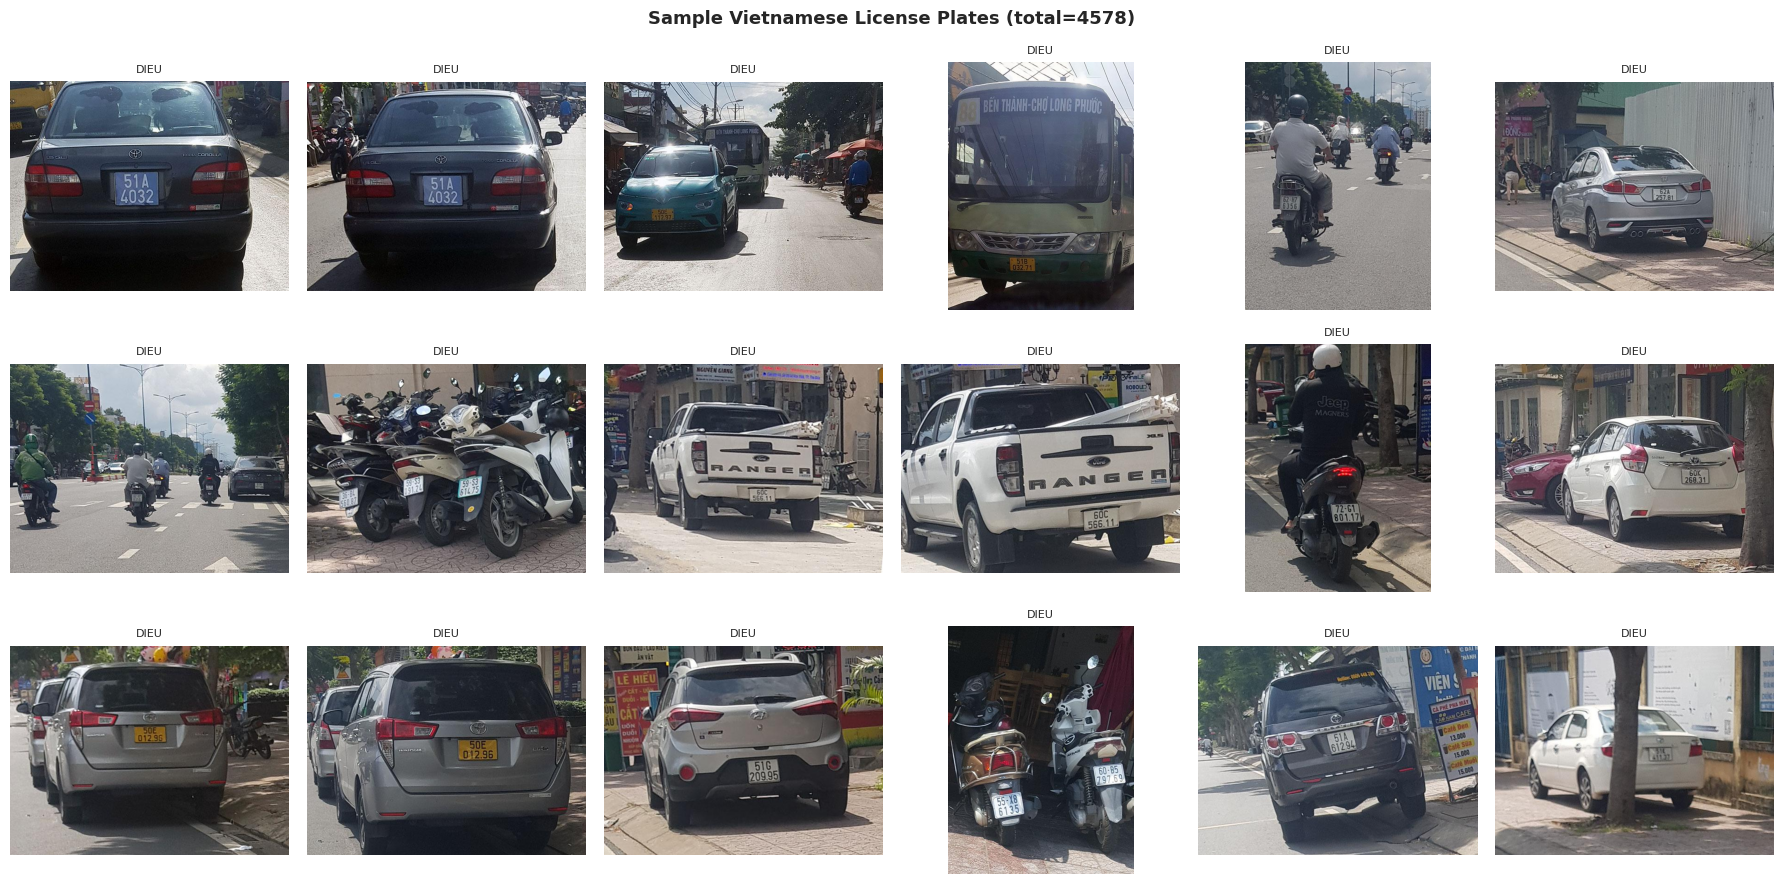

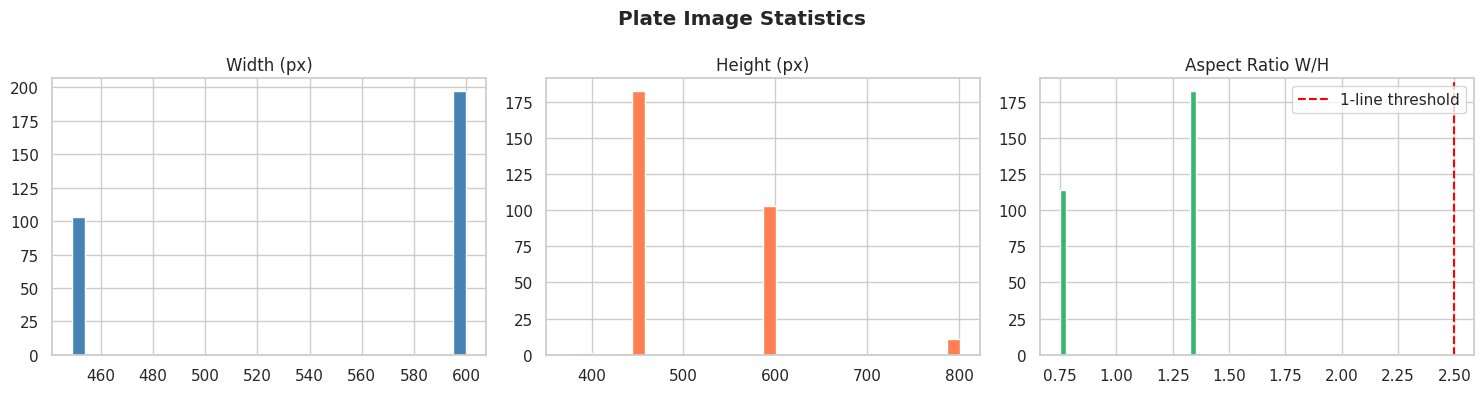

Aspect ratio — Mean: 1.11 | 1-line (>2.5): 0 | 2-line (≤2.5): 300


In [8]:
# ── Plate image samples ───────────────────────────────────────────────────
n_show = min(18, len(PLATE_IMAGES))
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for ax, path in zip(axes.flatten(), PLATE_IMAGES[:n_show]):
    img = cv2.imread(str(path))
    if img is None:
        ax.axis('off'); continue
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(parse_label(path)[:12], fontsize=8)
    ax.axis('off')
for ax in axes.flatten()[n_show:]:
    ax.axis('off')
plt.suptitle(f'Sample Vietnamese License Plates (total={len(PLATE_IMAGES)})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Plate dimension statistics ────────────────────────────────────────────
widths, heights, aspects = [], [], []
for p in PLATE_IMAGES[:300]:
    img = cv2.imread(str(p))
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w); heights.append(h); aspects.append(w / h)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths,  bins=30, color='steelblue',      edgecolor='white'); axes[0].set_title('Width (px)')
axes[1].hist(heights, bins=30, color='coral',          edgecolor='white'); axes[1].set_title('Height (px)')
axes[2].hist(aspects, bins=30, color='mediumseagreen', edgecolor='white')
axes[2].axvline(2.5, color='red', linestyle='--', label='1-line threshold')
axes[2].set_title('Aspect Ratio W/H'); axes[2].legend()
plt.suptitle('Plate Image Statistics', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Aspect ratio — Mean: {np.mean(aspects):.2f} | '
      f'1-line (>2.5): {sum(a>2.5 for a in aspects)} | '
      f'2-line (≤2.5): {sum(a<=2.5 for a in aspects)}')

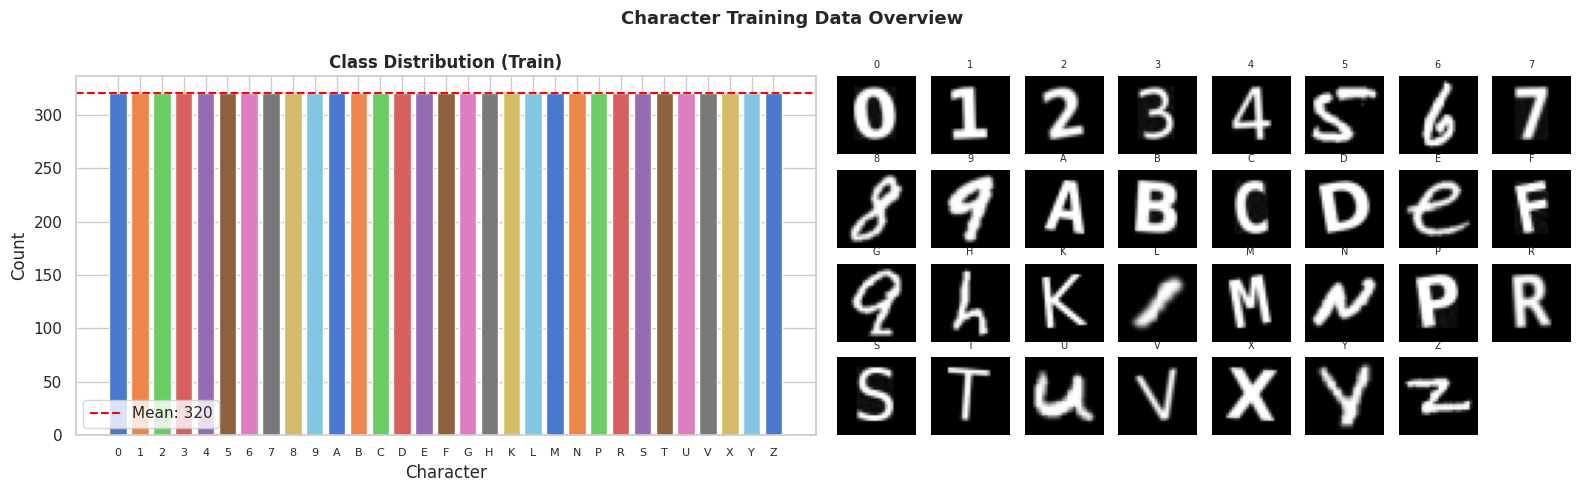

Min: 320 | Max: 320 | Std: 0.0 samples/class


In [9]:
# ── Character class distribution ──────────────────────────────────────────
counts = pd.Series(y_train).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(counts)), counts.values,
            color=sns.color_palette('muted', len(counts)))
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels([CHAR_LIST[i] for i in counts.index], fontsize=8)
axes[0].axhline(counts.mean(), color='red', linestyle='--',
                label=f'Mean: {counts.mean():.0f}')
axes[0].set_title('Class Distribution (Train)', fontweight='bold')
axes[0].set_xlabel('Character'); axes[0].set_ylabel('Count')
axes[0].legend()

# Sample grid — one image per class
inner = gridspec.GridSpecFromSubplotSpec(4, 8, subplot_spec=axes[1].get_subplotspec(),
                                         wspace=0.1, hspace=0.2)
axes[1].axis('off')
for i in range(min(32, N_CLASSES)):
    row, col = divmod(i, 8)
    ax = fig.add_subplot(inner[row, col])
    idxs = np.where(y_train == i)[0]
    if len(idxs):
        ax.imshow(X_train[idxs[0]], cmap='gray')
    ax.set_title(CHAR_LIST[i], fontsize=7); ax.axis('off')

plt.suptitle('Character Training Data Overview', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Min: {counts.min()} | Max: {counts.max()} | Std: {counts.std():.1f} samples/class')

## 3. Preprocessing & Deskew

**Pipeline per plate:**
1. CLAHE (L channel in LAB) — tăng tương phản
2. Bilateral filter — khử nhiễu, giữ cạnh
3. `deskew_plate()` — MinAreaRect → xoay về ngang
4. `deskew_with_fallback()` — thử cả 0° và 180°, chọn hướng có nhiều ký tự segment hơn

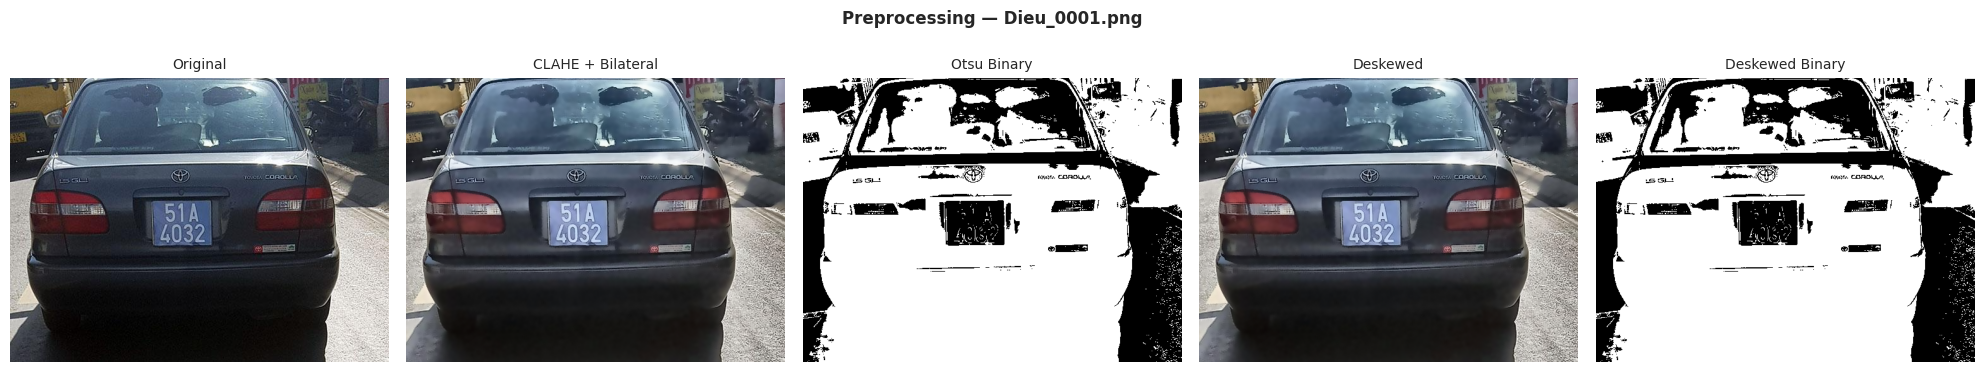

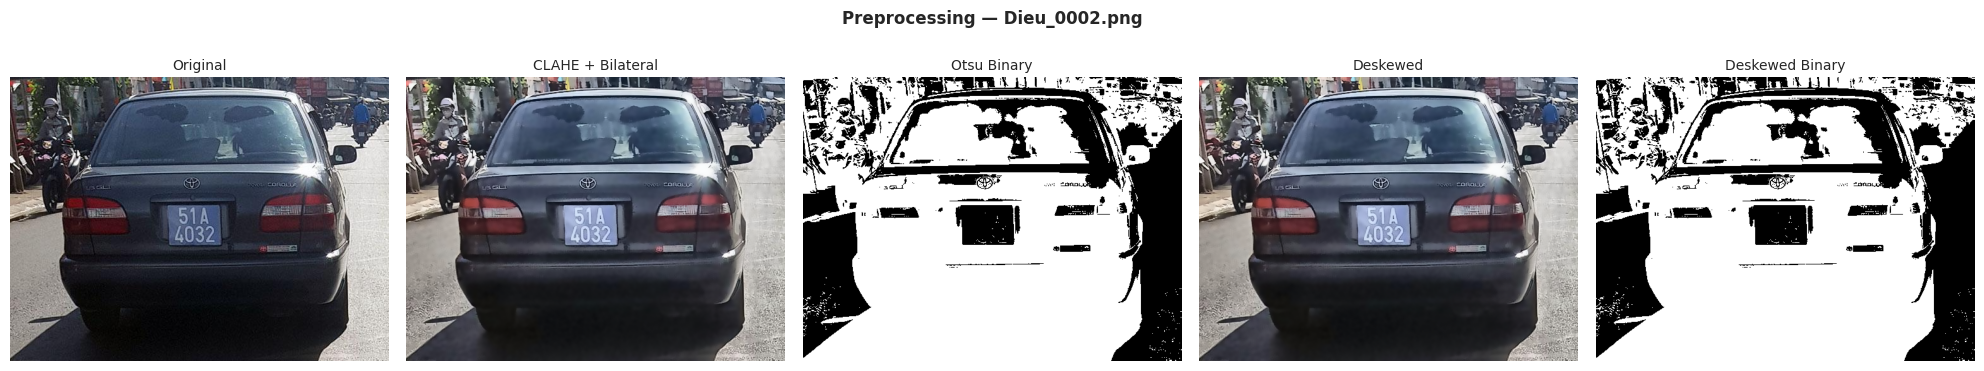

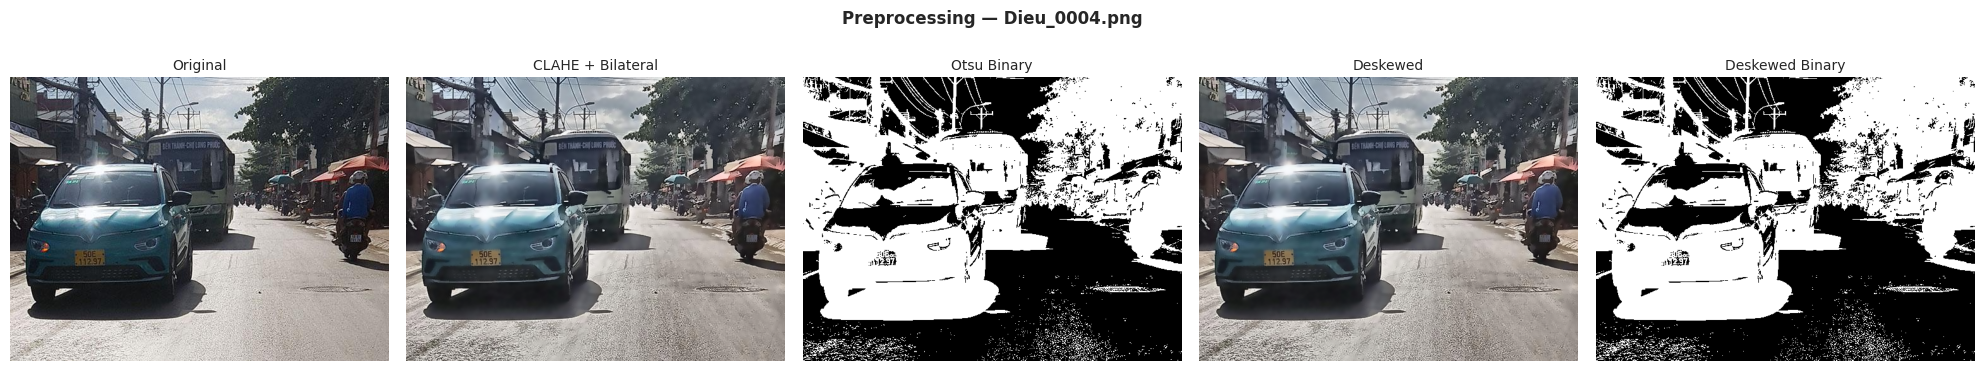

In [10]:
from src.preprocessing import preprocess_scene_image, deskew_plate, deskew_with_fallback

def show_preprocessing(path, figsize=(20, 4)):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None: return
    orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    proc     = preprocess_scene_image(orig)            # CLAHE + bilateral
    gray     = cv2.cvtColor(proc, cv2.COLOR_RGB2GRAY)
    _, otsu  = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    deskewed = deskew_with_fallback(proc)              # deskew + 180° fallback
    gray_dk  = cv2.cvtColor(deskewed, cv2.COLOR_RGB2GRAY)
    _, bin_dk = cv2.threshold(gray_dk, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    steps = [orig, proc, otsu, deskewed, bin_dk]
    titles = ['Original', 'CLAHE + Bilateral', 'Otsu Binary', 'Deskewed', 'Deskewed Binary']
    cmaps  = [None, None, 'gray', None, 'gray']

    fig, axes = plt.subplots(1, 5, figsize=figsize)
    for ax, s, t, c in zip(axes, steps, titles, cmaps):
        ax.imshow(s, cmap=c); ax.set_title(t, fontsize=10); ax.axis('off')
    plt.suptitle(f'Preprocessing — {path.name}', fontweight='bold', fontsize=12)
    plt.tight_layout(); plt.show()

# Demo on first 3 plates
for p in PLATE_IMAGES[:3]:
    show_preprocessing(p)

In [11]:
# ── Evaluate deskew improvement (char count before/after) ────────────────
from src.segmentation import segment_plate
from src.plate_classifier import classify_plate_type

records = []
for path in tqdm(PLATE_IMAGES[:80], desc='Deskew evaluation'):
    img = cv2.imread(str(path))
    if img is None: continue
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    try:
        pt, _ = classify_plate_type(rgb)
        n_before = len(segment_plate(rgb, pt)[0])
    except: n_before = 0

    try:
        dk = deskew_with_fallback(preprocess_scene_image(rgb))
        pt, _ = classify_plate_type(dk)
        n_after = len(segment_plate(dk, pt)[0])
    except: n_after = 0

    records.append({'before': n_before, 'after': n_after})

df_dsk = pd.DataFrame(records)
print(f'Avg chars  BEFORE deskew: {df_dsk["before"].mean():.2f}')
print(f'Avg chars  AFTER  deskew: {df_dsk["after"].mean():.2f}')
improved = (df_dsk['after'] > df_dsk['before']).sum()
same     = (df_dsk['after'] == df_dsk['before']).sum()
worse    = (df_dsk['after'] < df_dsk['before']).sum()
print(f'Improved: {improved} | Same: {same} | Worse: {worse}')

Deskew evaluation:   0%|          | 0/80 [00:00<?, ?it/s]

Avg chars  BEFORE deskew: 1.26
Avg chars  AFTER  deskew: 1.99
Improved: 36 | Same: 34 | Worse: 10


## 4. Feature Extraction — 4 Methods

| Method | Dim | Notes |
|--------|-----|-------|
| Raw pixel | 784 | Flatten 28×28, normalise [0,1] — baseline |
| HOG | ~324 | Histogram of Oriented Gradients — robust to small rotation |
| Haar Wavelet | 196 | `cA2 + cH2 + cV2 + cD2` flattened (4×7×7) — multi-resolution |
| ResNet18 frozen | 512 | ImageNet pretrained, **không fine-tune** — tốt nhất |

> **ResNet18 frozen không phải deep learning** theo nghĩa bài toán: chỉ dùng làm bộ trích đặc trưng cố định, bộ phân loại cuối vẫn là SVM / RF / Logistic / KNN.

In [12]:
from sklearn.preprocessing import StandardScaler
from src.features import (
    extract_features       as extract_resnet,
    extract_hog_features   as extract_hog,
    extract_wavelet_features as extract_wavelet,
    extract_raw_features   as extract_raw,
)

FEATURE_METHODS = {
    'Raw (784-d)':        extract_raw,
    'HOG (~324-d)':       extract_hog,
    'Wavelet (196-d)':    extract_wavelet,
    'ResNet18 (512-d)':   extract_resnet,
}
print('Feature extractors:', list(FEATURE_METHODS.keys()))

Feature extractors: ['Raw (784-d)', 'HOG (~324-d)', 'Wavelet (196-d)', 'ResNet18 (512-d)']


In [13]:
FEATURE_CACHE = {}
print(f'Extracting features — Train: {len(X_train)} | Test: {len(X_test)}\n')

for name, fn in FEATURE_METHODS.items():
    t0 = time.time()
    print(f'  [{name}]', end=' ', flush=True)
    Xtr = fn(list(X_train))
    Xte = fn(list(X_test))
    elapsed = time.time() - t0
    FEATURE_CACHE[name] = (Xtr, Xte)
    print(f'shape={Xtr.shape}  time={elapsed:.1f}s')

print('\n✅ All features extracted and cached.')

Extracting features — Train: 9920 | Test: 2480

  [Raw (784-d)] shape=(9920, 784)  time=0.1s
  [HOG (~324-d)] shape=(9920, 1296)  time=4.8s
  [Wavelet (196-d)] shape=(9920, 196)  time=1.5s
  [ResNet18 (512-d)] Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/zgsnat/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:11<00:00, 4.11MB/s]


✅ ResNet18 Feature Extractor loaded successfully.
shape=(9920, 512)  time=42.9s

✅ All features extracted and cached.


## 5. 4×4 Experiment Matrix

**16 experiments = 4 features × 4 classifiers**

| | Logistic | SVM (RBF) | KNN (k=5) | Random Forest |
|---|---|---|---|---|
| Raw (784-d) | ✓ | ✓ | ✓ | ✓ |
| HOG (~324-d) | ✓ | ✓ | ✓ | ✓ |
| Wavelet (196-d) | ✓ | ✓ | ✓ | ✓ |
| ResNet18 (512-d) | ✓ | ✓ | ✓ | ✓ |

In [14]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

CLASSIFIERS = {
    'Logistic':      lambda: LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1, random_state=42),
    'SVM (RBF)':     lambda: SVC(C=10, kernel='rbf', gamma='scale', probability=True, random_state=42),
    'KNN (k=5)':     lambda: KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
}
print('Classifiers:', list(CLASSIFIERS.keys()))

Classifiers: ['Logistic', 'SVM (RBF)', 'KNN (k=5)', 'Random Forest']


In [15]:
results_list = []
BEST_MODELS  = {}   # best model per feature method (for demo)

header = f'{"Experiment":<38} {"Acc":>6} {"F1":>6} {"Train(s)":>9} {"Inf(ms)":>8}'
print(header)
print('=' * len(header))

for feat_name, (Xtr_f, Xte_f) in FEATURE_CACHE.items():
    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(Xtr_f)
    Xte_s  = scaler.transform(Xte_f)

    for clf_name, clf_fn in CLASSIFIERS.items():
        clf = clf_fn()

        t1 = time.time(); clf.fit(Xtr_s, y_train); train_t = time.time() - t1
        t2 = time.time(); y_pred = clf.predict(Xte_s)
        inf_ms = (time.time() - t2) / len(X_test) * 1000

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)

        key = f'{feat_name} + {clf_name}'
        results_list.append({
            'Feature': feat_name, 'Classifier': clf_name,
            'Accuracy': acc, 'Macro F1': f1,
            'Train Time (s)': round(train_t, 2),
            'Inf Time (ms)': round(inf_ms, 3),
            'y_pred': y_pred,
        })

        if feat_name not in BEST_MODELS or acc > BEST_MODELS[feat_name]['acc']:
            BEST_MODELS[feat_name] = {
                'acc': acc, 'clf': clf, 'scaler': scaler,
                'feat_fn': FEATURE_METHODS[feat_name],
            }

        print(f'{key:<38} {acc:>6.4f} {f1:>6.4f} {train_t:>9.2f} {inf_ms:>8.3f}')

print(f'\n✅ All {len(results_list)} experiments complete!')

Experiment                                Acc     F1  Train(s)  Inf(ms)
Raw (784-d) + Logistic                 0.8012 0.8004    486.38    0.004
Raw (784-d) + SVM (RBF)                0.8569 0.8591     53.64    2.715
Raw (784-d) + KNN (k=5)                0.8052 0.8063      0.01    0.207
Raw (784-d) + Random Forest            0.8613 0.8607      1.03    0.044
HOG (~324-d) + Logistic                0.8875 0.8875    792.89    0.003
HOG (~324-d) + SVM (RBF)               0.9048 0.9050    114.33    5.056
HOG (~324-d) + KNN (k=5)               0.8492 0.8509      0.00    0.239
HOG (~324-d) + Random Forest           0.8931 0.8923      1.29    0.022
Wavelet (196-d) + Logistic             0.8004 0.7998    119.04    0.000
Wavelet (196-d) + SVM (RBF)            0.8480 0.8499     22.12    0.858
Wavelet (196-d) + KNN (k=5)            0.7786 0.7813      0.00    0.041
Wavelet (196-d) + Random Forest        0.8609 0.8598      0.68    0.025
ResNet18 (512-d) + Logistic            0.9089 0.9090    316.53  

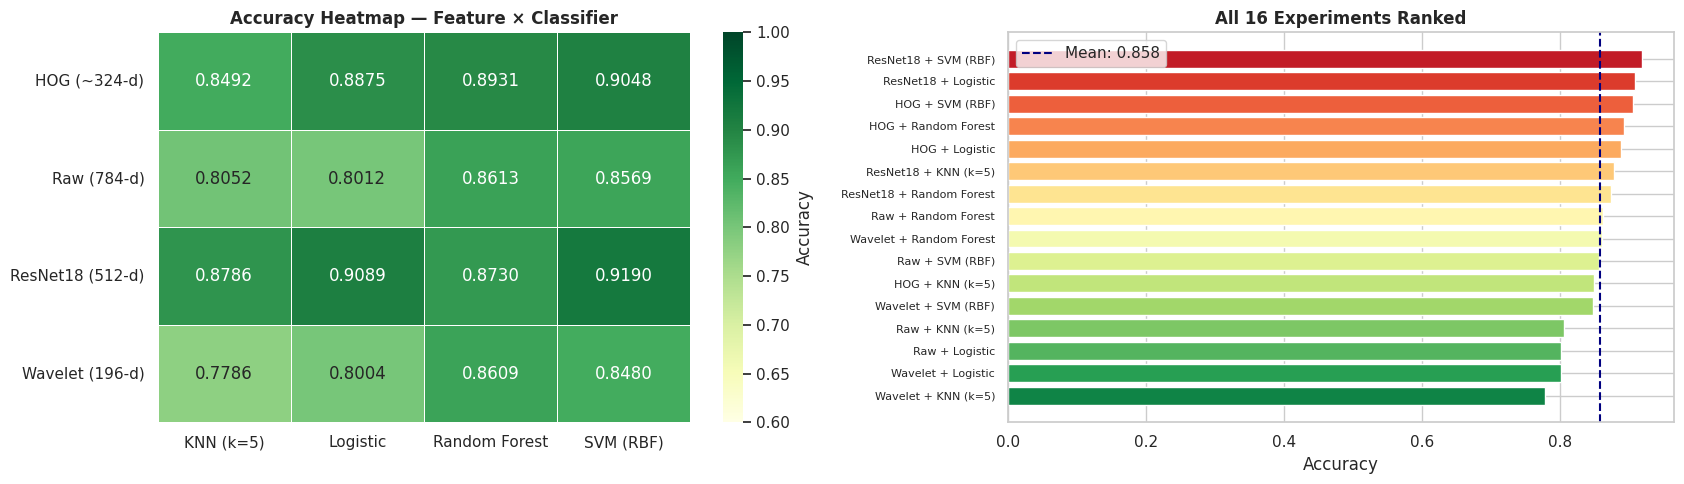


Top 5:
         Feature    Classifier  Accuracy  Macro F1  Train Time (s)  Inf Time (ms)
ResNet18 (512-d)     SVM (RBF)  0.918952  0.918551           31.63          2.005
ResNet18 (512-d)      Logistic  0.908871  0.908959          316.53          0.003
    HOG (~324-d)     SVM (RBF)  0.904839  0.904952          114.33          5.056
    HOG (~324-d) Random Forest  0.893145  0.892331            1.29          0.022
    HOG (~324-d)      Logistic  0.887500  0.887466          792.89          0.003


In [16]:
results_df = (
    pd.DataFrame(results_list)
    .drop(columns=['y_pred'])
    .sort_values('Accuracy', ascending=False)
    .reset_index(drop=True)
)

pivot_acc = results_df.pivot(index='Feature', columns='Classifier', values='Accuracy')

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Accuracy heatmap
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.6, vmax=1.0, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Accuracy Heatmap — Feature × Classifier', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')

# Ranked bar chart
colors = sns.color_palette('RdYlGn', len(results_df))
labels = [f"{r['Feature'].split('(')[0].strip()} + {r['Classifier']}"
          for _, r in results_df.iterrows()]
axes[1].barh(range(len(results_df)), results_df['Accuracy'],
             color=colors, edgecolor='white')
axes[1].set_yticks(range(len(results_df)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].invert_yaxis()
axes[1].axvline(results_df['Accuracy'].mean(), color='navy', linestyle='--',
                label=f'Mean: {results_df["Accuracy"].mean():.3f}')
axes[1].set_xlabel('Accuracy'); axes[1].set_title('All 16 Experiments Ranked', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5:')
print(results_df[['Feature','Classifier','Accuracy','Macro F1',
                  'Train Time (s)','Inf Time (ms)']].head(5).to_string(index=False))

## 6. Evaluation

Best model: Raw (784-d) + Logistic  (Acc=0.8012)


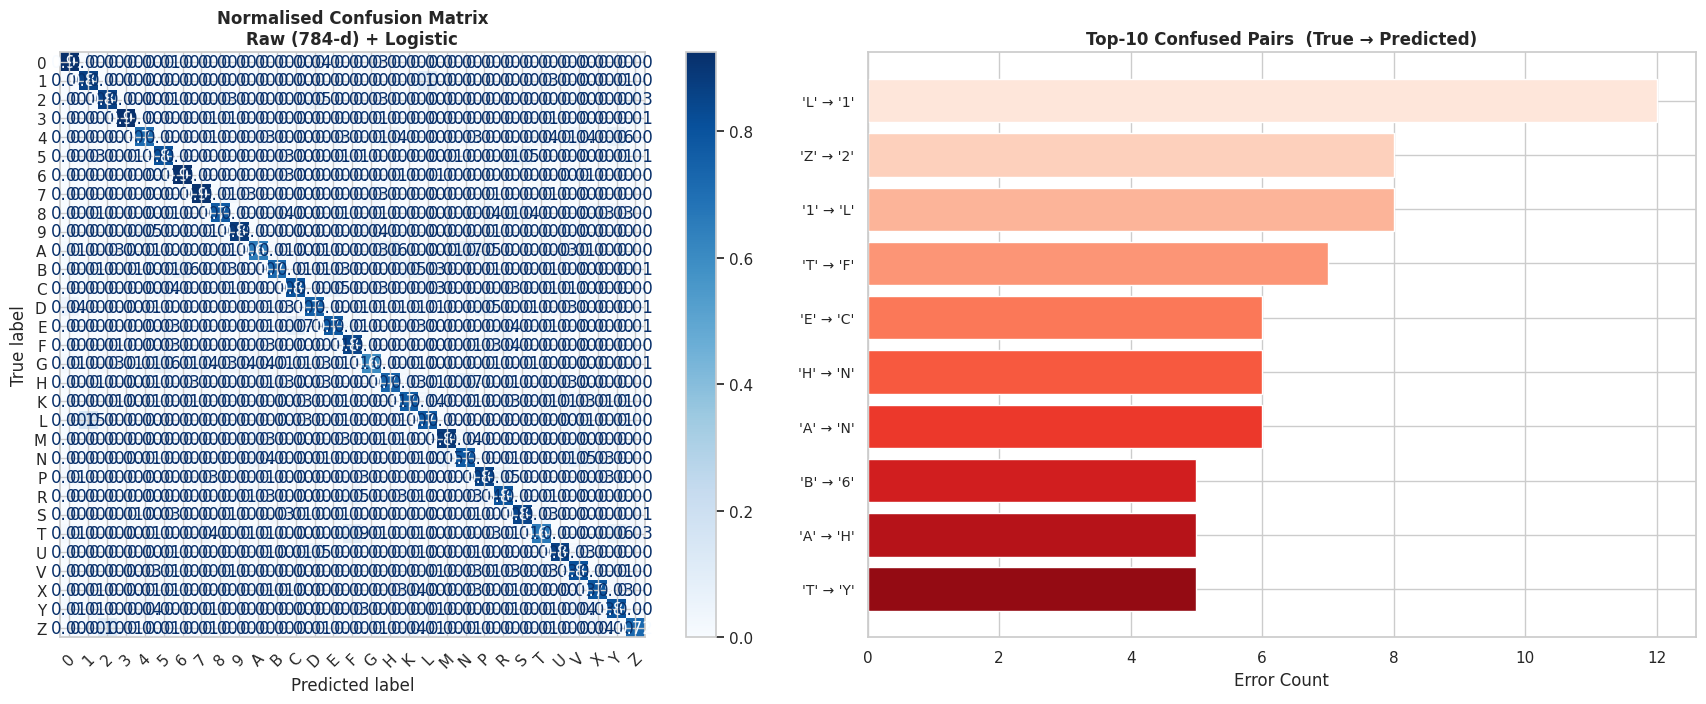

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Best overall model
best_row  = results_list[results_df.index[0]]
best_key  = f"{best_row['Feature']} + {best_row['Classifier']}"
print(f'Best model: {best_key}  (Acc={best_row["Accuracy"]:.4f})')

cm      = confusion_matrix(y_test, best_row['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

disp = ConfusionMatrixDisplay(cm_norm, display_labels=CHAR_LIST)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues',
          values_format='.2f', xticks_rotation=45)
axes[0].set_title(f'Normalised Confusion Matrix\n{best_key}', fontweight='bold')

# Top-10 most confused pairs
errors = cm.copy(); np.fill_diagonal(errors, 0)
top_idx = np.unravel_index(np.argsort(errors.ravel())[-15:], errors.shape)
pairs = sorted(
    [(CHAR_LIST[i], CHAR_LIST[j], errors[i,j]) for i,j in zip(*top_idx) if errors[i,j]>0],
    key=lambda x: x[2], reverse=True
)[:10]
pair_labels = [f"'{t}' → '{p}'" for t,p,_ in pairs]
pair_counts = [c for _,_,c in pairs]

axes[1].barh(range(len(pair_labels)), pair_counts[::-1],
             color=sns.color_palette('Reds_r', len(pair_labels)))
axes[1].set_yticks(range(len(pair_labels)))
axes[1].set_yticklabels(pair_labels[::-1], fontsize=10)
axes[1].set_xlabel('Error Count')
axes[1].set_title('Top-10 Confused Pairs  (True → Predicted)', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

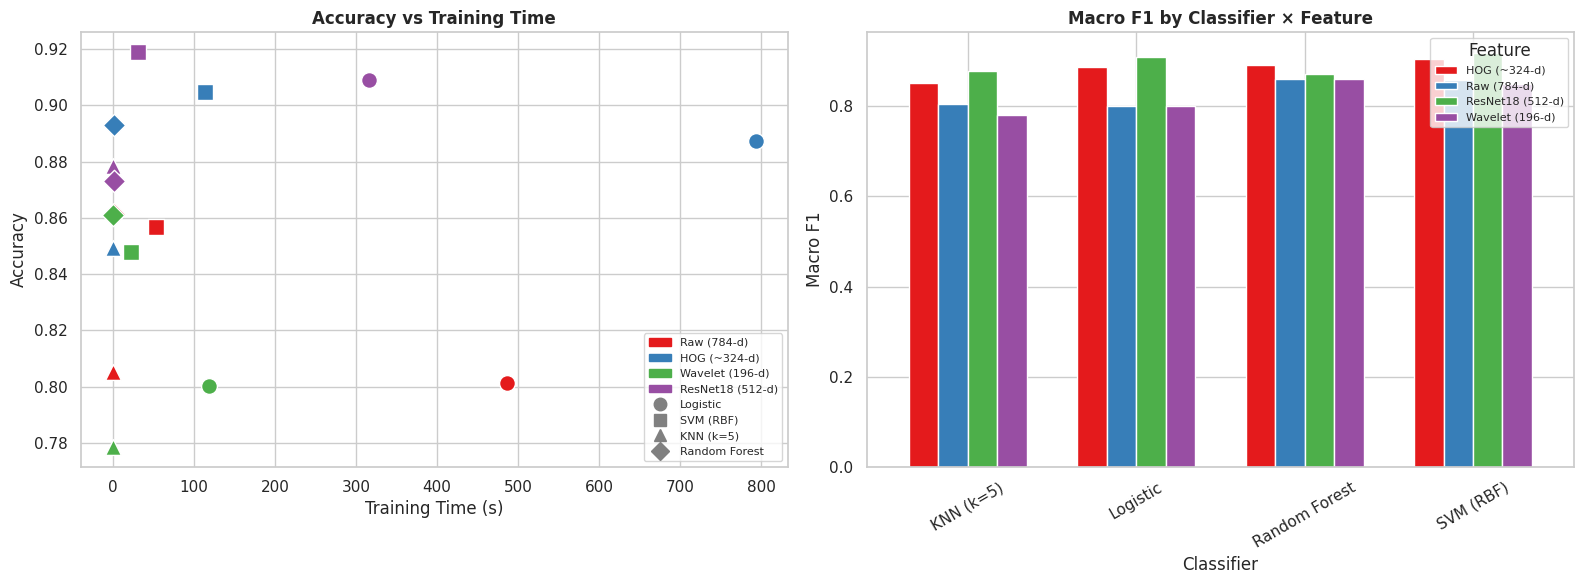

In [18]:
# ── Accuracy vs Training Time + F1 comparison ─────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

feat_colors = {f: c for f, c in
               zip(FEATURE_METHODS.keys(), sns.color_palette('Set1', 4))}
clf_markers = {'Logistic': 'o', 'SVM (RBF)': 's', 'KNN (k=5)': '^', 'Random Forest': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for _, row in results_df.iterrows():
    axes[0].scatter(row['Train Time (s)'], row['Accuracy'],
                    color=feat_colors[row['Feature']],
                    marker=clf_markers[row['Classifier']],
                    s=130, zorder=5, edgecolors='white', linewidth=1)

legend_feat = [Patch(color=c, label=f) for f, c in feat_colors.items()]
legend_clf  = [Line2D([0],[0], marker=m, color='gray', markersize=9, label=c, linestyle='None')
               for c, m in clf_markers.items()]
axes[0].legend(handles=legend_feat + legend_clf, fontsize=8, loc='lower right')
axes[0].set_xlabel('Training Time (s)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Training Time', fontweight='bold')

pivot_f1 = results_df.pivot(index='Classifier', columns='Feature', values='Macro F1')
pivot_f1.plot(kind='bar', ax=axes[1],
              color=list(feat_colors.values()), edgecolor='white', width=0.7)
axes[1].set_title('Macro F1 by Classifier × Feature', fontweight='bold')
axes[1].set_xlabel('Classifier'); axes[1].set_ylabel('Macro F1')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].legend(title='Feature', fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tradeoff_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Dimensionality Reduction Visualisation

| Method | Type | When to use |
|--------|------|-------------|
| **PCA** | Linear | Baseline — fast, interpretable |
| **t-SNE** | Non-linear | Preserves local cluster structure |
| **UMAP** | Non-linear | Local + global structure, faster than t-SNE |

Feature space used: **HOG** (good trade-off, ~324-d)

Visualising 3000 samples...
PCA    0.3s  var=10.2%


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

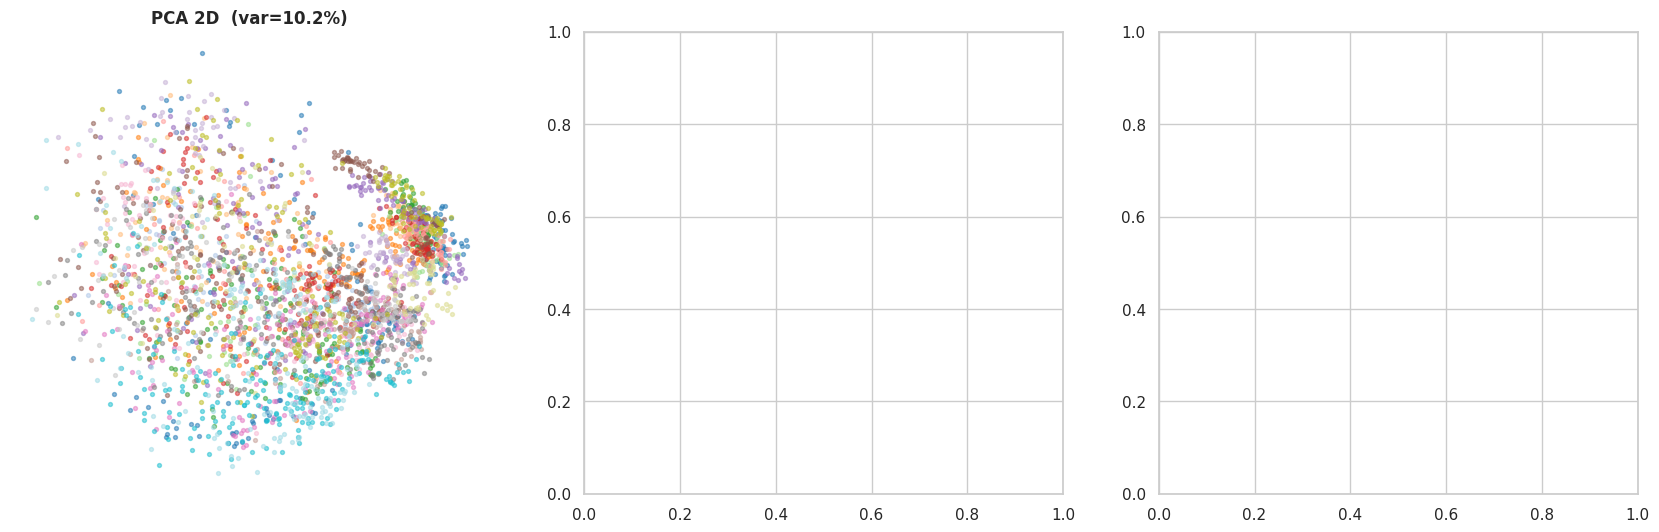

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

feat_viz = 'HOG (~324-d)'
Xtr_viz, _ = FEATURE_CACHE[feat_viz]
scaler_viz  = StandardScaler()
Xv = scaler_viz.fit_transform(Xtr_viz)

N_VIZ = min(3000, len(Xv))
idx_v = np.random.RandomState(42).choice(len(Xv), N_VIZ, replace=False)
Xs, ys = Xv[idx_v], y_train[idx_v]
print(f'Visualising {N_VIZ} samples...')

colors = plt.cm.get_cmap('tab20', N_CLASSES)(np.linspace(0, 1, N_CLASSES))
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ── PCA ───────────────────────────────────────────────────────────────────
t0 = time.time()
pca  = PCA(n_components=2, random_state=42)
Xpca = pca.fit_transform(Xs)
print(f'PCA    {time.time()-t0:.1f}s  var={pca.explained_variance_ratio_.sum()*100:.1f}%')
for c in range(N_CLASSES):
    m = ys == c
    if m.any(): axes[0].scatter(Xpca[m,0], Xpca[m,1], c=[colors[c]], s=8, alpha=0.5)
axes[0].set_title(f'PCA 2D  (var={pca.explained_variance_ratio_.sum()*100:.1f}%)',
                  fontweight='bold'); axes[0].axis('off')

# ── t-SNE ─────────────────────────────────────────────────────────────────
t0 = time.time()
tsne  = TSNE(n_components=2, perplexity=40, n_iter=500, random_state=42, n_jobs=-1)
Xtsne = tsne.fit_transform(Xs)
print(f't-SNE  {time.time()-t0:.1f}s')
for c in range(N_CLASSES):
    m = ys == c
    if m.any(): axes[1].scatter(Xtsne[m,0], Xtsne[m,1], c=[colors[c]], s=8, alpha=0.5)
axes[1].set_title('t-SNE 2D', fontweight='bold'); axes[1].axis('off')

# ── UMAP ──────────────────────────────────────────────────────────────────
try:
    import umap
    t0 = time.time()
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
    Xumap   = reducer.fit_transform(Xs)
    print(f'UMAP   {time.time()-t0:.1f}s')
    for c in range(N_CLASSES):
        m = ys == c
        if m.any(): axes[2].scatter(Xumap[m,0], Xumap[m,1], c=[colors[c]], s=8, alpha=0.5)
    axes[2].set_title('UMAP 2D', fontweight='bold')
except ImportError:
    axes[2].text(0.5, 0.5, 'umap-learn not installed\npip install umap-learn',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
axes[2].axis('off')

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color=colors[i], label=CHAR_LIST[i]) for i in range(N_CLASSES)],
    loc='lower center', ncol=N_CLASSES, fontsize=7, title='Class',
    bbox_to_anchor=(0.5, -0.03)
)
plt.suptitle(f'Feature Space ({feat_viz}, n={N_VIZ})', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/feature_visualization.png')

## 8. End-to-End Pipeline Demo

Chạy toàn bộ pipeline từ ảnh biển số → chuỗi ký tự:
```
plate image → preprocess → deskew → segment chars → extract features → classify → plate string
```

In [ ]:
# Use the best overall model
best_feat_name = results_df.iloc[0]['Feature']
best_clf_name  = results_df.iloc[0]['Classifier']
print(f'Best model: {best_feat_name} + {best_clf_name}')

best_info  = BEST_MODELS[best_feat_name]
best_clf   = best_info['clf']
best_scaler= best_info['scaler']
best_feat  = best_info['feat_fn']

def segment_chars_from_plate(img_rgb):
    proc  = preprocess_scene_image(img_rgb)
    dk    = deskew_with_fallback(proc)
    pt, ar= classify_plate_type(dk)
    chars, info, binary = segment_plate(dk, pt)
    return chars, info, binary, pt, ar

def recognize_plate(path):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        return {'success': False, 'path': str(path)}
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    chars, _, binary, plate_type, ar = segment_chars_from_plate(img_rgb)
    result = {
        'success': False, 'path': str(path),
        'original': img_rgb, 'binary': binary,
        'plate_type': plate_type, 'ar': ar,
        'char_count': len(chars),
    }
    if not chars:
        return result

    feats  = best_feat(chars)
    feats_s= best_scaler.transform(feats)
    preds  = best_clf.predict(feats_s)
    pred_chars  = [CHAR_LIST[p] for p in preds]
    plate_string= ''.join(pred_chars)

    result.update({'success': True, 'plate_string': plate_string, 'predictions': pred_chars})
    return result

print('E2E pipeline ready.')

In [ ]:
n_demo = min(6, len(PLATE_IMAGES))
demo_results = []

print('Running end-to-end demo...\n')
for p in PLATE_IMAGES[:n_demo]:
    res = recognize_plate(p)
    gt  = parse_label(p)
    pred= res.get('plate_string', 'N/A')
    match = '✅' if pred == gt else '⚠️'
    print(f'  {p.name:<30}  GT: {gt:<12}  Pred: {pred:<12}  {match}')
    demo_results.append((res, gt))

# ── Visualise ────────────────────────────────────────────────────────────
fig, all_axes = plt.subplots(n_demo, 3, figsize=(16, 4 * n_demo))
if n_demo == 1:
    all_axes = all_axes.reshape(1, -1)

for row_idx, (res, gt) in enumerate(demo_results):
    axes = all_axes[row_idx]
    if res.get('original') is None:
        for ax in axes: ax.axis('off')
        continue

    axes[0].imshow(res['original'])
    axes[0].set_title('Original', fontsize=9); axes[0].axis('off')

    axes[1].imshow(res['binary'], cmap='gray')
    axes[1].set_title(f'Binary  ({res["plate_type"]}, AR={res["ar"]:.2f}, {res["char_count"]} chars)',
                      fontsize=9)
    axes[1].axis('off')

    pred = res.get('plate_string', 'N/A')
    color = 'green' if pred == gt else 'red'
    axes[2].axis('off')
    axes[2].text(0.5, 0.65, f'GT:   {gt}',   ha='center', va='center', fontsize=15,
                 fontweight='bold', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.35, f'Pred: {pred}', ha='center', va='center', fontsize=15,
                 color=color, fontweight='bold', transform=axes[2].transAxes)

plt.suptitle(f'End-to-End Demo — {best_feat_name} + {best_clf_name}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'e2e_demo.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nSaved → {RESULTS_DIR}/e2e_demo.png')